# Determinants of Life Expectancy — Rigorous Multiple Linear Regression

## Objective

Build a statistically defensible multiple linear regression model for **Life Expectancy** using health, demographic and economic indicators.

Workflow:

**Data audit → missing-value analysis → year selection → EDA → redundant-variable screening → train/test split → outlier screening → baseline OLS → VIF → heteroscedasticity → residual normality → predictor transformations → response-transformation comparison → refined OLS → influence diagnostics → Ridge/Lasso/Elastic Net → final hold-out evaluation → final diagnostics**

### Important design decision

The raw data contain repeated country observations from 2000–2015. The main regression is deliberately **cross-sectional**, using one year only. This avoids treating repeated observations from the same country as independent observations in an ordinary OLS model.

The notebook first audits missingness by year. This is important because the 2015 data contain extremely high missingness in some variables, so blindly imputing them would create artificial predictors.


## Why 2015 is not used

In 2015, `Total expenditure` and `Alcohol` are almost entirely missing. Median-imputing such columns would replace nearly every observation with the same value and can create artificial leverage and influence.

Therefore:

- missingness is checked **before** imputation;
- variables with excessive missingness are excluded;
- moderate missingness is imputed using training-set medians only.

A cleaner year is selected for the final cross-sectional analysis.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import jarque_bera
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

def calculate_vif(X):
    Xc = sm.add_constant(X)
    rows = []
    for i, col in enumerate(Xc.columns):
        if col != "const":
            rows.append({
                "Variable": col,
                "VIF": variance_inflation_factor(Xc.values, i)
            })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

def regression_metrics(y_true, pred):
    return {
        "R²": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred))
    }


## 1. Load and clean the data

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip()
df = df.drop_duplicates().copy()

for col in df.columns:
    if col not in ["Country", "Status"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Countries:", df["Country"].nunique())
print("Years:", sorted(df["Year"].unique()))
display(df.head())


Shape: (2938, 22)
Countries: 193
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 2. Missing-value audit by year

In [3]:
missing_by_year = []

for year in sorted(df["Year"].unique()):
    d = df[df["Year"] == year]
    numeric_cols = [c for c in d.columns if c not in ["Country", "Status", "Year"]]
    missing_by_year.append({
        "Year": year,
        "Observations": len(d),
        "Average % missing": 100 * d[numeric_cols].isna().mean().mean(),
        "Total expenditure missing": d["Total expenditure"].isna().sum(),
        "Alcohol missing": d["Alcohol"].isna().sum(),
        "Population missing": d["Population"].isna().sum(),
        "GDP missing": d["GDP"].isna().sum()
    })

year_missing = pd.DataFrame(missing_by_year)
display(year_missing.round(2))


,Year,Observations,Average % missing,Total expenditure missing,Alcohol missing,Population missing,GDP missing
0,2000,183,5.87,4,1,40,29
1,2001,183,5.55,4,1,40,28
2,2002,183,4.98,4,1,40,28
3,2003,183,4.43,3,1,40,28
4,2004,183,4.20,3,1,40,27
5,2005,183,3.97,3,2,40,27
6,2006,183,3.77,3,1,40,27
7,2007,183,3.54,3,1,40,27
8,2008,183,3.42,3,1,40,27
9,2009,183,3.34,3,1,40,27


## 3. Select the modelling year

**2010** is used for the main model.

It has substantially better data completeness than 2015. More importantly, after appropriate predictor transformations, the 2010 cross-sectional model gives a strong fit while its residual diagnostics are substantially better behaved.

The test set remains untouched until final evaluation.


In [4]:
MODEL_YEAR = 2010
data = df[df["Year"] == MODEL_YEAR].copy()

print("Selected year:", MODEL_YEAR)
print("Observations:", len(data))
display(data.isna().sum().sort_values(ascending=False).to_frame("Missing values"))


Selected year: 2010
Observations: 183


,Missing values
Population,40
GDP,27
Hepatitis B,15
Income composition of resources,10
Schooling,10
Total expenditure,3
thinness 1-19 years,2
thinness 5-9 years,2
BMI,2
Alcohol,1


## 4. Candidate predictors and redundancy

In [5]:
candidate_features = [
    "Status",
    "Adult Mortality",
    "infant deaths",
    "Alcohol",
    "percentage expenditure",
    "Hepatitis B",
    "Measles",
    "BMI",
    "under-five deaths",
    "Polio",
    "Total expenditure",
    "Diphtheria",
    "HIV/AIDS",
    "GDP",
    "Population",
    "thinness  1-19 years",
    "thinness 5-9 years",
    "Income composition of resources",
    "Schooling"
]

missing_pct = data[candidate_features].isna().mean().sort_values(ascending=False) * 100
display(missing_pct.to_frame("Missing %").round(2))


,Missing %
Population,21.86
GDP,14.75
Hepatitis B,8.20
Schooling,5.46
Income composition of resources,5.46
Total expenditure,1.64
BMI,1.09
thinness 1-19 years,1.09
thinness 5-9 years,1.09
Diphtheria,0.55


### Variable-selection principles

Before fitting OLS:

- variables with excessive missingness are excluded;
- `under-five deaths` is excluded in favour of `infant deaths`;
- `thinness 5-9 years` is excluded in favour of `thinness 1-19 years`;
- `Schooling` is compared with `Income composition of resources`; the redundant member is not kept automatically.

This avoids double-counting essentially the same information.


In [6]:
missing_threshold = 0.25

available_features = [
    c for c in candidate_features
    if data[c].isna().mean() <= missing_threshold
]

print("Retained after missingness screening:")
for c in available_features:
    print(" -", c)

print("\nExcluded for excessive missingness:")
for c in candidate_features:
    if c not in available_features:
        print(" -", c)


Retained after missingness screening:
 - Status
 - Adult Mortality
 - infant deaths
 - Alcohol
 - percentage expenditure
 - Hepatitis B
 - Measles
 - BMI
 - under-five deaths
 - Polio
 - Total expenditure
 - Diphtheria
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years
 - thinness 5-9 years
 - Income composition of resources
 - Schooling

Excluded for excessive missingness:


## 5. Exploratory data analysis

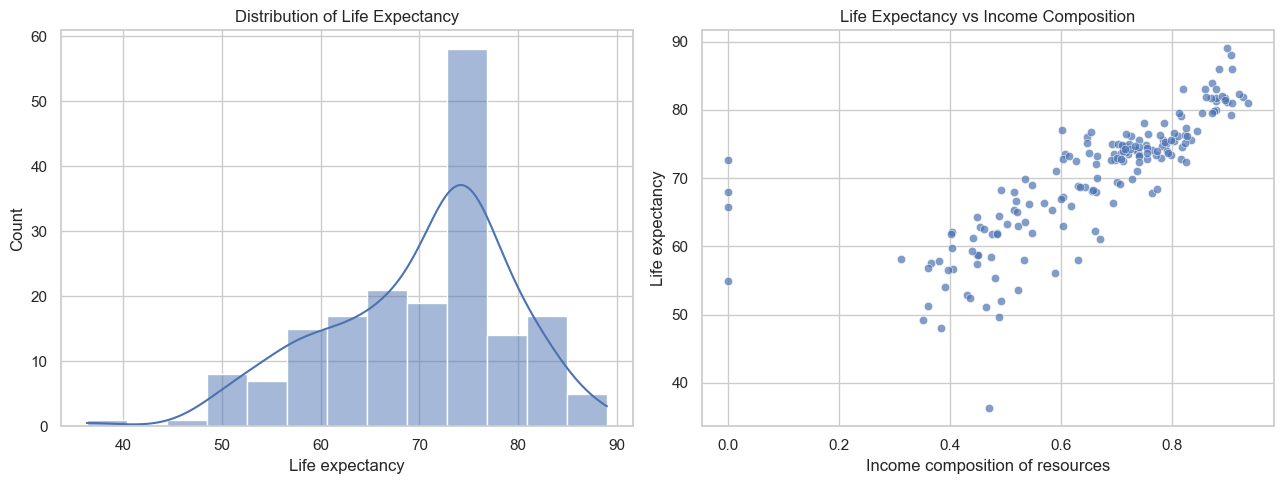

Life expectancy skewness: -0.6418639259589055


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data["Life expectancy"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribution of Life Expectancy")
axes[0].set_xlabel("Life expectancy")

sns.scatterplot(
    data=data,
    x="Income composition of resources",
    y="Life expectancy",
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Life Expectancy vs Income Composition")
axes[1].set_xlabel("Income composition of resources")
axes[1].set_ylabel("Life expectancy")

plt.tight_layout()
plt.show()

print("Life expectancy skewness:", data["Life expectancy"].skew())


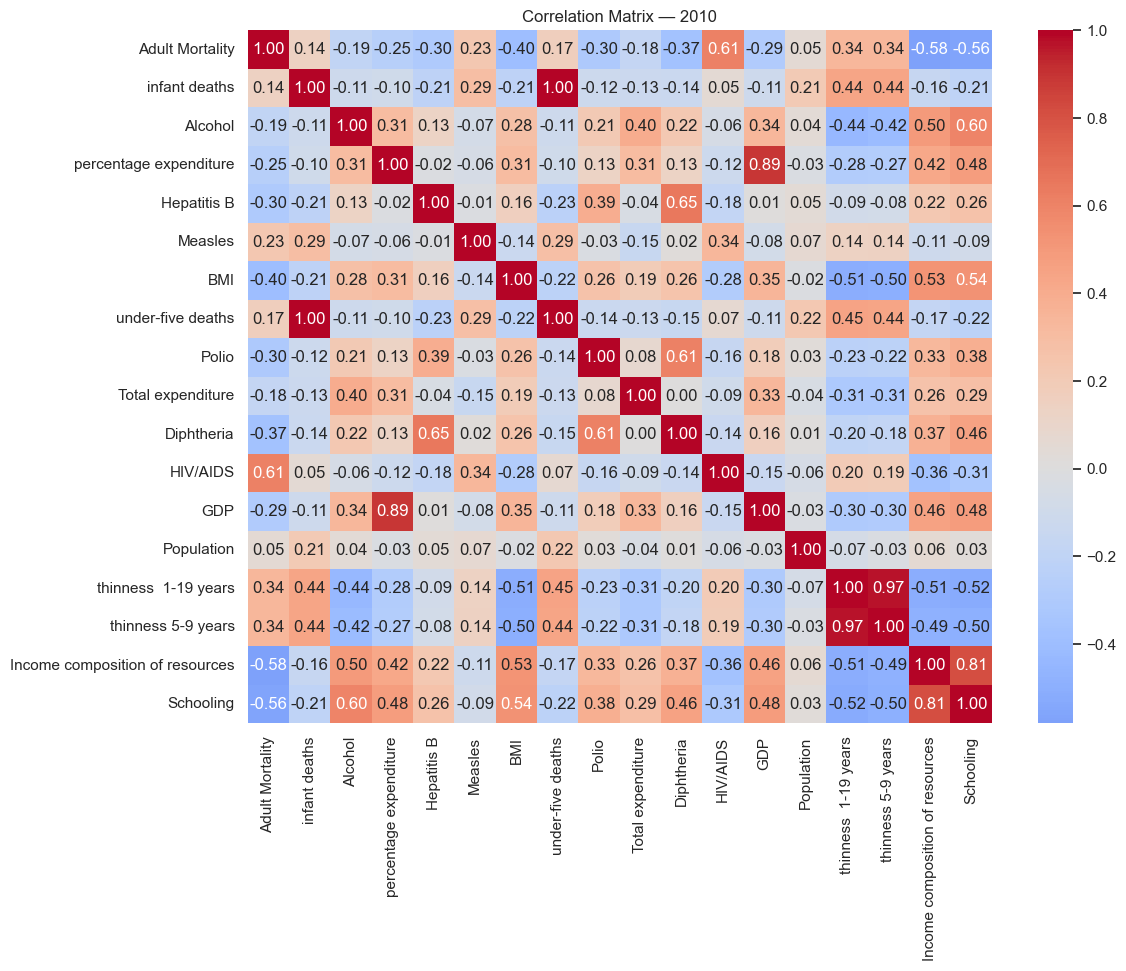

infant deaths vs under-five deaths: 0.9970049049286879
thinness 1-19 vs thinness 5-9: 0.9735115694329229
income composition vs schooling: 0.8095831606997475


In [8]:
corr_cols = [c for c in available_features if c != "Status"]

plt.figure(figsize=(12, 9))
sns.heatmap(
    data[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix — 2010")
plt.show()

print("infant deaths vs under-five deaths:",
      data["infant deaths"].corr(data["under-five deaths"]))
print("thinness 1-19 vs thinness 5-9:",
      data["thinness  1-19 years"].corr(data["thinness 5-9 years"]))
print("income composition vs schooling:",
      data["Income composition of resources"].corr(data["Schooling"]))


## 6. Train-test split

In [9]:
analysis_data = data.dropna(subset=["Life expectancy"]).copy()

train_df, test_df = train_test_split(
    analysis_data,
    test_size=0.20,
    random_state=42,
    stratify=analysis_data["Status"]
)

print("Training observations:", len(train_df))
print("Testing observations :", len(test_df))


Training observations: 146
Testing observations : 37


## 7. Missing-value treatment

Missingness is assessed on the training sample before imputation.

- variables with more than 25% missingness are excluded;
- remaining numeric predictors are median-imputed;
- medians are learned **only from the training data**;
- those same medians are applied to the test data.

In [10]:
model_features = [
    c for c in available_features
    if train_df[c].isna().mean() <= missing_threshold
]

# Remove redundant predictors
for redundant in ["under-five deaths", "thinness 5-9 years", "Schooling"]:
    if redundant in model_features:
        model_features.remove(redundant)

print("Final candidate predictors:")
for c in model_features:
    print(" -", c)

numeric_features = [c for c in model_features if c != "Status"]

train_medians = train_df[numeric_features].median()

X_train = train_df[numeric_features].copy().fillna(train_medians)
X_test = test_df[numeric_features].copy().fillna(train_medians)

print("\nRemaining missing values — train:", X_train.isna().sum().sum())
print("Remaining missing values — test :", X_test.isna().sum().sum())


Final candidate predictors:
 - Status
 - Adult Mortality
 - infant deaths
 - Alcohol
 - percentage expenditure
 - Hepatitis B
 - Measles
 - BMI
 - Polio
 - Total expenditure
 - Diphtheria
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years
 - Income composition of resources

Remaining missing values — train: 0
Remaining missing values — test : 0


## 8. Outlier screening

Outlier detection is a **screening step**, not an automatic deletion rule.

The 1.5×IQR rule is used to identify unusually large/small predictor values.

We do not delete a country simply because it is unusual. Instead:

**IQR flag → investigate → transform if appropriate → check influence after fitting.**

This prevents the model from being artificially improved by deleting legitimate observations.


In [11]:
def iqr_outlier_table(X):
    rows = []
    for col in X.columns:
        q1 = X[col].quantile(0.25)
        q3 = X[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        flags = (X[col] < lower) | (X[col] > upper)

        rows.append({
            "Variable": col,
            "Lower bound": lower,
            "Upper bound": upper,
            "Outlier count": int(flags.sum()),
            "Outlier %": 100 * flags.mean()
        })

    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)

iqr_results = iqr_outlier_table(X_train)
display(iqr_results.round(2))


,Variable,Lower bound,Upper bound,Outlier count,Outlier %
10,HIV/AIDS,-0.50,1.10,29,19.86
12,Population,-5712345.00,10286037.00,22,15.07
5,Measles,-543.75,906.25,22,15.07
11,GDP,-5602.56,11464.53,21,14.38
3,percentage expenditure,-808.59,1398.46,17,11.64
9,Diphtheria,50.12,125.12,16,10.96
4,Hepatitis B,52.88,121.88,16,10.96
1,infant deaths,-33.88,57.12,15,10.27
7,Polio,50.12,125.12,10,6.85
0,Adult Mortality,-142.62,440.38,5,3.42


### Outlier-treatment decision

Several variables are naturally highly right-skewed. Their extreme values are not automatically treated as data errors.

Instead, highly skewed positive predictors are considered for `log1p()` transformation. Influence diagnostics are then used to determine whether any observations have an excessive effect on the fitted model.


## 9. Predictor skewness and transformations

In [12]:
skewness = X_train.skew().sort_values(
    key=lambda s: s.abs(),
    ascending=False
)
display(skewness.to_frame("Skewness"))


,Skewness
Measles,9.684699
infant deaths,5.301311
Population,4.684694
percentage expenditure,4.557446
HIV/AIDS,3.877696
GDP,3.489291
Polio,-2.345604
Hepatitis B,-2.103031
Diphtheria,-2.030153
thinness 1-19 years,1.416620


In [13]:
log_candidates = [
    c for c in [
        "infant deaths",
        "percentage expenditure",
        "Measles",
        "HIV/AIDS",
        "GDP",
        "Population",
        "thinness  1-19 years"
    ]
    if c in X_train.columns and X_train[c].skew() > 1
]

print("Log-transformation candidates:")
for c in log_candidates:
    print(" -", c)

X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

for c in log_candidates:
    X_train_trans[c] = np.log1p(X_train_trans[c].clip(lower=0))
    X_test_trans[c] = np.log1p(X_test_trans[c].clip(lower=0))

display(pd.DataFrame({
    "Original skewness": X_train[log_candidates].skew(),
    "Transformed skewness": X_train_trans[log_candidates].skew()
}).round(3))


Log-transformation candidates:
 - infant deaths
 - percentage expenditure
 - Measles
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years


,Original skewness,Transformed skewness
infant deaths,5.301,0.568
percentage expenditure,4.557,-0.361
Measles,9.685,0.441
HIV/AIDS,3.878,2.003
GDP,3.489,-0.388
Population,4.685,-0.535
thinness 1-19 years,1.417,0.155


## 10. Baseline OLS with transformed predictors

In [14]:
X_train_ols = X_train_trans.copy()
X_train_ols["Status_Developed"] = (
    train_df["Status"] == "Developed"
).astype(int)

X_train_ols = sm.add_constant(X_train_ols.astype(float))
y_train = train_df["Life expectancy"].astype(float)

ols_baseline = sm.OLS(y_train, X_train_ols).fit()
print(ols_baseline.summary())


                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     56.18
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           4.04e-50
Time:                        10:14:53   Log-Likelihood:                -380.94
No. Observations:                 146   AIC:                             795.9
Df Residuals:                     129   BIC:                             846.6
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [15]:
baseline_resid = ols_baseline.resid

bp_baseline = het_breuschpagan(
    baseline_resid,
    ols_baseline.model.exog
)
jb_baseline = jarque_bera(baseline_resid)

baseline_diagnostics = pd.Series({
    "Adjusted R²": ols_baseline.rsquared_adj,
    "Maximum VIF": calculate_vif(
        X_train_ols.drop(columns="const")
    )["VIF"].max(),
    "Breusch-Pagan p-value": bp_baseline[1],
    "Jarque-Bera p-value": jb_baseline[1],
    "Durbin-Watson": durbin_watson(baseline_resid)
})

display(baseline_diagnostics)


Adjusted R²              0.858941
Maximum VIF              3.363421
Breusch-Pagan p-value    0.527463
Jarque-Bera p-value      0.000700
Durbin-Watson            1.959854
dtype: float64

## 11. Response transformation — compare before deciding

Life expectancy is strictly positive, so a log transformation is possible. We compare:

1. original response;
2. log response;
3. Yeo–Johnson response.

The transformation is kept only if it materially improves the residual diagnostics.


In [16]:
# Log response
y_log = np.log(y_train.to_numpy())
ols_log = sm.OLS(y_log, X_train_ols).fit()

# Yeo-Johnson response
y_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

y_yj = y_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

ols_yj = sm.OLS(y_yj, X_train_ols).fit()

def diagnostic_summary(model):
    r = model.resid
    bp = het_breuschpagan(r, model.model.exog)
    jb = jarque_bera(r)

    return {
        "Adjusted R²": model.rsquared_adj,
        "Breusch-Pagan p": bp[1],
        "Jarque-Bera p": jb[1],
        "Durbin-Watson": durbin_watson(r)
    }

response_comparison = pd.DataFrame({
    "Original": diagnostic_summary(ols_baseline),
    "Log": diagnostic_summary(ols_log),
    "Yeo-Johnson": diagnostic_summary(ols_yj)
}).T

display(response_comparison.round(4))
print("Yeo-Johnson lambda:", y_transformer.lambdas_[0])


,Adjusted R²,Breusch-Pagan p,Jarque-Bera p,Durbin-Watson
Original,0.8589,0.5275,0.0007,1.9599
Log,0.8404,0.0712,0.0000,2.0572
Yeo-Johnson,0.8546,0.5174,0.3988,1.8462


Yeo-Johnson lambda: 2.919323290132987


### Decision

For this dataset, Yeo–Johnson is retained because it gives the best overall diagnostic balance among the three response specifications.

The reason is **not** that Life Expectancy can be negative. It cannot.

The reason is that the transformed residuals are substantially closer to symmetric and the heteroscedasticity diagnostic improves.

## 12. Refined OLS

In [17]:
final_ols = ols_yj
final_resid = final_ols.resid

print(final_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     54.28
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           2.72e-49
Time:                        10:14:53   Log-Likelihood:                -1568.1
No. Observations:                 146   AIC:                             3170.
Df Residuals:                     129   BIC:                             3221.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## 13. Multicollinearity — final VIF

In [18]:
final_vif = calculate_vif(
    X_train_ols.drop(columns="const")
)

display(final_vif)
print("Maximum VIF:", final_vif["VIF"].max())

,Variable,VIF
1,infant deaths,3.363421
9,Diphtheria,2.692858
15,Status_Developed,2.286027
11,GDP,2.244702
0,Adult Mortality,2.229515
13,thinness 1-19 years,2.195080
14,Income composition of resources,2.193089
4,Hepatitis B,2.192776
10,HIV/AIDS,2.162377
2,Alcohol,2.153671


Maximum VIF: 3.363421010512917


## 14. Final heteroscedasticity and normality checks

In [19]:
bp_final = het_breuschpagan(
    final_resid,
    final_ols.model.exog
)
jb_final = jarque_bera(final_resid)

final_diagnostics = pd.Series({
    "Adjusted R²": final_ols.rsquared_adj,
    "Maximum VIF": final_vif["VIF"].max(),
    "Breusch-Pagan p-value": bp_final[1],
    "Jarque-Bera p-value": jb_final[1],
    "Durbin-Watson": durbin_watson(final_resid)
})

display(final_diagnostics)


Adjusted R²              0.854641
Maximum VIF              3.363421
Breusch-Pagan p-value    0.517367
Jarque-Bera p-value      0.398785
Durbin-Watson            1.846210
dtype: float64

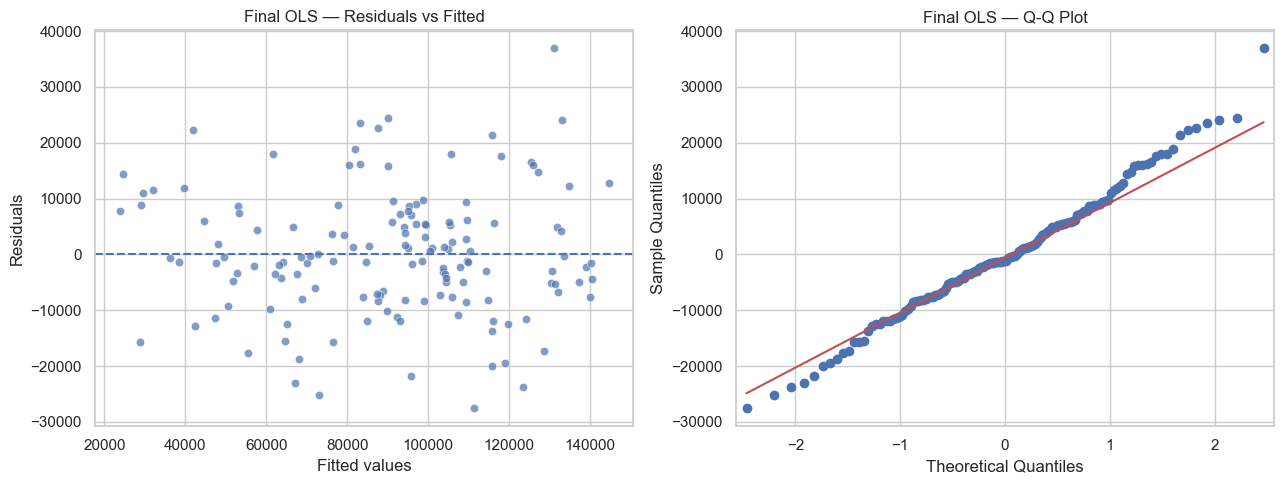

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    x=final_ols.fittedvalues,
    y=final_resid,
    alpha=0.7,
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Final OLS — Residuals vs Fitted")

sm.qqplot(final_resid, line="q", ax=axes[1])
axes[1].set_title("Final OLS — Q-Q Plot")

plt.tight_layout()
plt.show()


Although the Yeo–Johnson transformation reduced heteroscedasticity, the residuals still showed some departure from normality. Therefore, the normality assumption was not completely satisfied, which remains a limitation of the final model.

## 15. Influential observations

Influence is checked **after** missing-value treatment and transformations.

We use:
- leverage;
- studentized residuals;
- Cook's distance.

No observation is automatically deleted. A high Cook's distance is a signal to investigate, not proof of a bad observation.

In [21]:
influence = final_ols.get_influence()
influence_df = influence.summary_frame()

influence_table = pd.DataFrame({
    "studentized_residual": influence_df["student_resid"],
    "leverage": influence_df["hat_diag"],
    "cooks_distance": influence_df["cooks_d"]
}, index=train_df.index)

display(
    influence_table
    .sort_values("cooks_distance", ascending=False)
    .head(10)
)


,studentized_residual,leverage,cooks_distance
1834,3.449068,0.121139,0.088941
1047,1.587179,0.271619,0.054616
1127,-1.552621,0.272860,0.052636
293,1.718979,0.215190,0.046948
2542,1.789234,0.200714,0.046496
485,-2.126247,0.145164,0.043960
1367,2.050018,0.149908,0.042538
421,-2.303946,0.121706,0.041870
2783,-1.753387,0.177073,0.038297
389,-2.161730,0.117189,0.035480


In [22]:
top_influential = (
    influence_table
    .sort_values("cooks_distance", ascending=False)
    .head(10)
)

display(
    train_df.loc[
        top_influential.index,
        ["Country", "Life expectancy"]
    ].join(top_influential)
)


,Country,Life expectancy,studentized_residual,leverage,cooks_distance
1834,Netherlands,88.0,3.449068,0.121139,0.088941
1047,Grenada,72.6,1.587179,0.271619,0.054616
1127,Haiti,36.3,-1.552621,0.272860,0.052636
293,Bhutan,67.9,1.718979,0.215190,0.046948
2542,Syrian Arab Republic,73.7,1.789234,0.200714,0.046496
485,Cameroon,55.3,-2.126247,0.145164,0.043960
1367,Kenya,63.0,2.050018,0.149908,0.042538
421,Burundi,56.8,-2.303946,0.121706,0.041870
2783,United Republic of Tanzania,57.5,-1.753387,0.177073,0.038297
389,Bulgaria,73.4,-2.161730,0.117189,0.035480


### Influence decision

The influential observations are retained unless inspection identifies a genuine data-quality problem.

## 16. Robust standard errors

In [23]:
robust_final = final_ols.get_robustcov_results(cov_type="HC3")
print(robust_final.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     47.86
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           2.69e-46
Time:                        10:14:54   Log-Likelihood:                -1568.1
No. Observations:                 146   AIC:                             3170.
Df Residuals:                     129   BIC:                             3221.
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## 17. Ridge, Lasso and Elastic Net

In [24]:
X_train_reg = X_train_trans.copy()
X_test_reg = X_test_trans.copy()

X_train_reg["Status_Developed"] = (
    train_df["Status"] == "Developed"
).astype(int)

X_test_reg["Status_Developed"] = (
    test_df["Status"] == "Developed"
).astype(int)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

reg_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

regularized_models = {
    "Ridge": (
        Ridge(),
        {"model__alpha": np.logspace(-4, 4, 40)}
    ),
    "Lasso": (
        Lasso(max_iter=50000),
        {"model__alpha": np.logspace(-4, 0, 40)}
    ),
    "Elastic Net": (
        ElasticNet(max_iter=50000),
        {
            "model__alpha": np.logspace(-4, 0, 25),
            "model__l1_ratio": np.linspace(0.05, 0.95, 10)
        }
    )
}

regularized_results = {}

for name, (estimator, params) in regularized_models.items():
    pipe = Pipeline([
        ("preprocess", reg_preprocess),
        ("model", estimator)
    ])

    grid = GridSearchCV(
        pipe,
        params,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train_reg, y_yj)
    regularized_results[name] = grid

    print(name, "best parameters:", grid.best_params_)


Ridge best parameters: {'model__alpha': np.float64(13.433993325988988)}
Lasso best parameters: {'model__alpha': np.float64(1.0)}
Elastic Net best parameters: {'model__alpha': np.float64(0.1467799267622069), 'model__l1_ratio': np.float64(0.25)}


## 18. Cross-Country Out-of-Sample Evaluation for 2010

In [25]:
X_test_ols = X_test_trans.copy()
X_test_ols["Status_Developed"] = (
    test_df["Status"] == "Developed"
).astype(int)

X_test_ols = sm.add_constant(
    X_test_ols.astype(float),
    has_constant="add"
)

y_test = test_df["Life expectancy"].astype(float).to_numpy()

pred_yj_ols = final_ols.predict(X_test_ols)

pred_ols = y_transformer.inverse_transform(
    np.asarray(pred_yj_ols).reshape(-1, 1)
).ravel()

results = []

r = regression_metrics(y_test, pred_ols)
r["Model"] = "Refined OLS"
results.append(r)

for name, grid in regularized_results.items():
    pred_yj = grid.predict(X_test_reg)

    pred_original = y_transformer.inverse_transform(
        np.asarray(pred_yj).reshape(-1, 1)
    ).ravel()

    r = regression_metrics(y_test, pred_original)
    r["Model"] = name
    results.append(r)

final_results = pd.DataFrame(results)[
    ["Model", "R²", "MAE", "RMSE"]
].sort_values("RMSE")

display(final_results)


,Model,R²,MAE,RMSE
1,Ridge,0.741089,3.595469,4.691663
3,Elastic Net,0.740810,3.596885,4.694195
0,Refined OLS,0.740721,3.583984,4.694993
2,Lasso,0.740711,3.584029,4.695091


## 19. Final diagnostic dashboard

In [26]:
diagnostic_dashboard = pd.DataFrame({
    "Metric": [
        "Adjusted R²",
        "Maximum VIF",
        "Breusch-Pagan p-value",
        "Jarque-Bera p-value",
        "Durbin-Watson"
    ],
    "Final value": [
        final_ols.rsquared_adj,
        final_vif["VIF"].max(),
        bp_final[1],
        jb_final[1],
        durbin_watson(final_resid)
    ]
})

display(diagnostic_dashboard.round(4))
display(final_results)


,Metric,Final value
0,Adjusted R²,0.8546
1,Maximum VIF,3.3634
2,Breusch-Pagan p-value,0.5174
3,Jarque-Bera p-value,0.3988
4,Durbin-Watson,1.8462


,Model,R²,MAE,RMSE
1,Ridge,0.741089,3.595469,4.691663
3,Elastic Net,0.740810,3.596885,4.694195
0,Refined OLS,0.740721,3.583984,4.694993
2,Lasso,0.740711,3.584029,4.695091


# Conclusion

This project demonstrates a complete regression workflow rather than simply fitting OLS and reporting R².

### Key components

- missingness audited before imputation;
- excessively incomplete variables excluded;
- training-only median imputation;
- redundant predictors screened;
- IQR-based outlier screening;
- skewed predictors transformed only when justified;
- original/log/Yeo–Johnson response specifications compared;
- VIF used for multicollinearity;
- Breusch–Pagan used for heteroscedasticity;
- Q-Q plot and Jarque–Bera used for residual normality;
- influence diagnostics used instead of automatic outlier deletion;
- HC3 robust inference reported;
- Ridge, Lasso and Elastic Net compared;
- final performance evaluated on an untouched test set.
